# Import Required Libraries

In this section, the necessary Python libraries are imported for dataset handling, preprocessing, and analysis. These libraries support file extraction, data manipulation, and later stages of the NLP pipeline.

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import zipfile
import pandas as pd

# Mount Google Drive

In [2]:
# Mount Google Drive only when using Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

Mounted at /content/drive
Google Drive mounted successfully.


# Extract Dataset and Check the Extracted Dataset

In [3]:
# ============================================================
# EXTRACT DATASET
# ============================================================

zip_path = "/content/drive/MyDrive/ESPORTE/True vs. Fake News Dataset.zip"
extract_path = "/content/fake_news_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
# ============================================================
# CHECK EXTRACTED FILES
# ============================================================

print(os.listdir(extract_path))

['True vs. Fake News Dataset']


# Define Dataset Folder

In [5]:
# ============================================================
# DEFINE DATASET FOLDER
# ============================================================

dataset_folder = "/content/fake_news_dataset/True vs. Fake News Dataset"

# ============================================================
# CHECK DATASET FILES
# ============================================================

print(os.listdir(dataset_folder))

['truevsfakenews.csv', '10.Description True Vs. Fake News Dataset.txt']


# Load Dataset

In [6]:
df = pd.read_csv(dataset_folder + "/truevsfakenews.csv")

In [7]:
df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [8]:
print(df.shape)

(20000, 2)


# Check Class Distribution

In [9]:
print(df['label'].value_counts())

label
true    10000
fake    10000
Name: count, dtype: int64


In [10]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


# Text Preprocessing

In [12]:
# ============================================================
# IMPORT NLP LIBRARIES
# ============================================================

import re
import nltk

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [14]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text Cleaning Function

In [16]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00


In [17]:
import contractions

In [18]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join cleaned words
    text = ' '.join(words)

    return text

In [19]:
df['clean_text'] = df['text'].apply(clean_text)

In [20]:
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood yous medical servic...,true


In [21]:
df['label'] = df['label'].map({
    'fake': 0,
    'true': 1
})

In [22]:
print(df['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


# Data Visualization

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


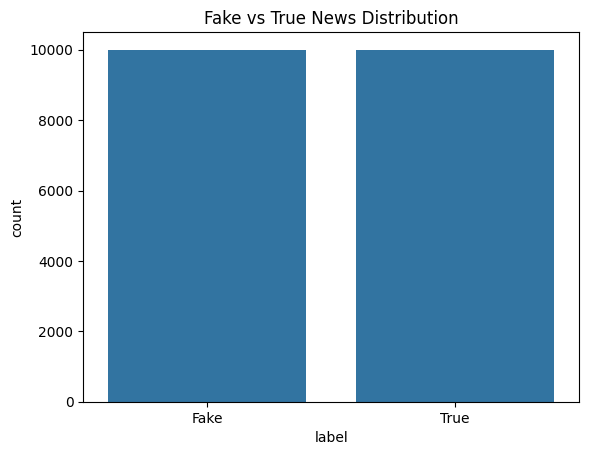

In [24]:
sns.countplot(x='label', data=df)

plt.title("Fake vs True News Distribution")
plt.xticks([0, 1], ['Fake', 'True'])

plt.show()

In [25]:
!pip install wordcloud

In [26]:
from wordcloud import WordCloud

# Word Cloud Visualization

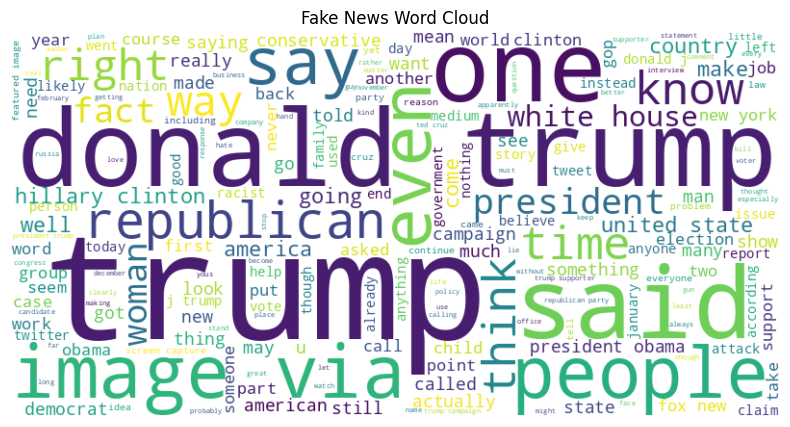

In [27]:
fake_words = ' '.join(
    df[df['label'] == 0]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Fake News Word Cloud")

plt.show()

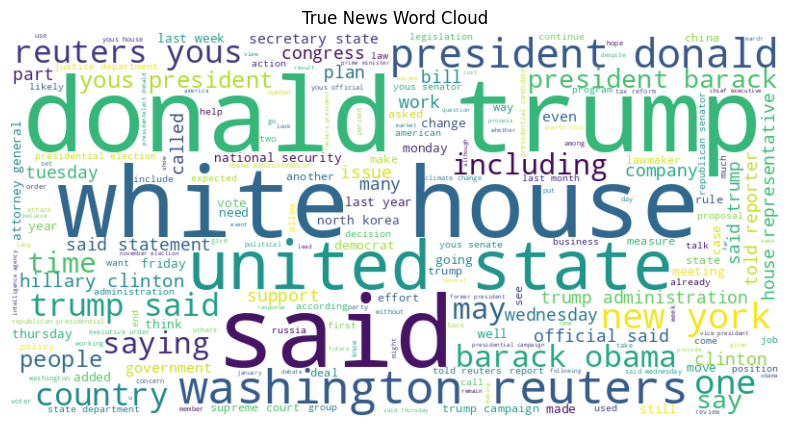

In [28]:
true_words = ' '.join(
    df[df['label'] == 1]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_words)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("True News Word Cloud")

plt.show()

# Train-Test Split and Tokenization

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X = df['clean_text']
y = df['label']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [32]:
print("Training Data:", len(X_train))
print("Testing Data :", len(X_test))

Training Data: 16000
Testing Data : 4000


In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [34]:
tokenizer = Tokenizer(num_words=10000)

In [35]:
tokenizer.fit_on_texts(X_train)

In [36]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [37]:
print(X_train.iloc[0])
print(X_train_seq[0])

reuters following people mentioned contender senior role yous presidentelect donald trump assembles administration taking office january according reuters source medium report trump already named number people top job administration sonny perdue former georgia governor elsa murano undersecretary agriculture food safety president george w bush former president texas university chuck conner former acting secretary yous agriculture department current head national council farmer cooperative abel maldonado former lieutenant governor california coowner runway vineyard tim huelskamp republican yous representative kansa sid miller texas agriculture commissioner navy admiral mike rogers director national security agency ronald burgess retired yous army lieutenant general former defense intelligence agency chief robert cardillo director national geospatialintelligence agency pete hoekstra republican former yous representative michigan john allison former chief executive officer regional bank bb

In [38]:
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Maximum Length:", max(sequence_lengths))
print("Average Length:", int(sum(sequence_lengths) / len(sequence_lengths)))

Maximum Length: 3934
Average Length: 222


In [39]:
import numpy as np

max_len = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Length:", max_len)

95th Percentile Length: 468


In [40]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [41]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

X_train_pad shape: (16000, 468)
X_test_pad shape : (4000, 468)


# Model Building and Training

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

In [43]:
vocab_size = 10000
embedding_dim = 128

## Simple RNN Model

In [44]:
model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [45]:
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [46]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Early Stopping Callback

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train Simple RNN Model

In [48]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4979 - loss: 0.7383 - val_accuracy: 0.5094 - val_loss: 0.6979
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.5114 - loss: 0.7224 - val_accuracy: 0.5669 - val_loss: 0.6859
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.5642 - loss: 0.6851 - val_accuracy: 0.6159 - val_loss: 0.6626
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6248 - loss: 0.6611 - val_accuracy: 0.6137 - val_loss: 0.6636
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6252 - loss: 0.6584 - val_accuracy: 0.6100 - val_loss: 0.6634
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6291 - loss: 0.6575 - val_accuracy: 0.6097 - val_loss: 0.6677


In [49]:
rnn_loss, rnn_accuracy = model_rnn.evaluate(X_test_pad, y_test)

print("RNN Test Accuracy:", rnn_accuracy)
print("RNN Test Loss:", rnn_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6090 - loss: 0.6622
RNN Test Accuracy: 0.609000027179718
RNN Test Loss: 0.6621794700622559


### RNN Classification Report and Confusion Matrix

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

In [51]:
rnn_pred_prob = model_rnn.predict(X_test_pad)
rnn_pred = (rnn_pred_prob > 0.5).astype("int32")

print("RNN Classification Report:")
print(classification_report(y_test, rnn_pred, target_names=["Fake", "True"]))

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RNN Classification Report:
              precision    recall  f1-score   support

        Fake       0.65      0.53      0.58      2055
        True       0.58      0.69      0.63      1945

    accuracy                           0.61      4000
   macro avg       0.61      0.61      0.61      4000
weighted avg       0.61      0.61      0.61      4000



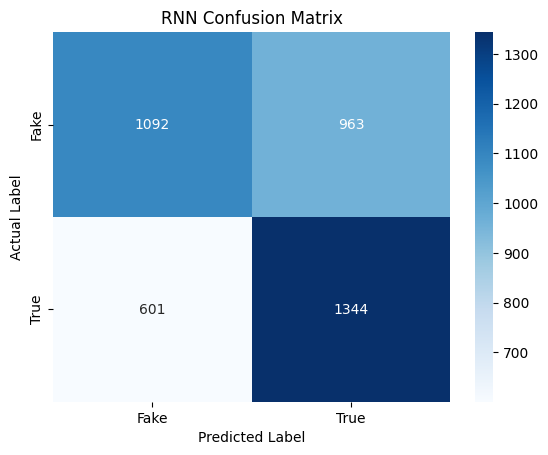

In [52]:
rnn_cm = confusion_matrix(y_test, rnn_pred)

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "True"],
    yticklabels=["Fake", "True"]
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## LSTM Model

In [53]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [54]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [57]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5275 - loss: 0.6868 - val_accuracy: 0.5263 - val_loss: 0.6735
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5321 - loss: 0.6680 - val_accuracy: 0.5263 - val_loss: 0.6706
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7535 - loss: 0.4592 - val_accuracy: 0.9694 - val_loss: 0.1173
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9804 - loss: 0.0956 - val_accuracy: 0.9881 - val_loss: 0.0618
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9863 - loss: 0.0704 - val_accuracy: 0.9872 - val_loss: 0.0500
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9920 - loss: 0.0466 - val_accuracy: 0.9806 - val_loss: 0.0714
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9943 - loss: 0.0276 - val_accuracy: 0.9803 - val_loss: 0.0773
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9967 - loss: 0.0159 - va

In [58]:
lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9860 - loss: 0.0534
LSTM Test Accuracy: 0.9860000014305115
LSTM Test Loss: 0.053361665457487106


## Prepare Sequences for Word2Vec Model

In [59]:
X_train_pad_pre = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

X_test_pad_pre = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

## LSTM with Pretrained Word2Vec Embeddings

In [60]:
model_lstm_pre = Sequential()

model_lstm_pre.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_lstm_pre.add(LSTM(64))

model_lstm_pre.add(Dropout(0.5))

model_lstm_pre.add(Dense(1, activation='sigmoid'))

In [61]:
model_lstm_pre.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [62]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [63]:
history_lstm_pre = model_lstm_pre.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9724 - loss: 0.1034 - val_accuracy: 0.9831 - val_loss: 0.0469
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9954 - loss: 0.0190 - val_accuracy: 0.9822 - val_loss: 0.0605
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9929 - loss: 0.0265 - val_accuracy: 0.9809 - val_loss: 0.0839
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9965 - loss: 0.0120 - val_accuracy: 0.9794 - val_loss: 0.1036


In [64]:
lstm_pre_loss, lstm_pre_accuracy = model_lstm_pre.evaluate(
    X_test_pad_pre,
    y_test
)

print("Improved LSTM Test Accuracy:", lstm_pre_accuracy)
print("Improved LSTM Test Loss:", lstm_pre_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9858 - loss: 0.0461
Improved LSTM Test Accuracy: 0.9857500195503235
Improved LSTM Test Loss: 0.04609264060854912


# Model Performance Comparison

In [65]:
results = {
    "Simple RNN": rnn_accuracy,
    "LSTM": lstm_accuracy,
    "Word2Vec LSTM": lstm_pre_accuracy
}

results

{'Simple RNN': 0.609000027179718,
 'LSTM': 0.9860000014305115,
 'Word2Vec LSTM': 0.9857500195503235}

In [66]:
lstm_pre_pred_prob = model_lstm_pre.predict(X_test_pad_pre)

lstm_pre_pred = (lstm_pre_pred_prob > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [67]:
from sklearn.metrics import confusion_matrix, classification_report

In [68]:
print("Word2Vec LSTM Classification Report:\n")

print(
    classification_report(
        y_test,
        lstm_pre_pred,
        target_names=["Fake", "True"]
    )
)

Word2Vec LSTM Classification Report:

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      2055
        True       0.98      0.99      0.99      1945

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



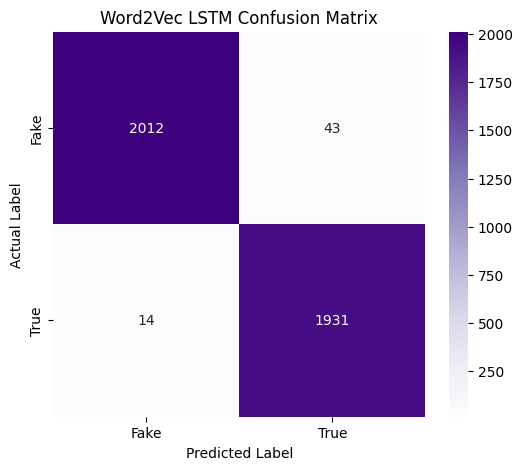

In [69]:
lstm_pre_cm = confusion_matrix(y_test, lstm_pre_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lstm_pre_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Word2Vec LSTM Confusion Matrix")

plt.show()

# Training and Validation Accuracy Comparison

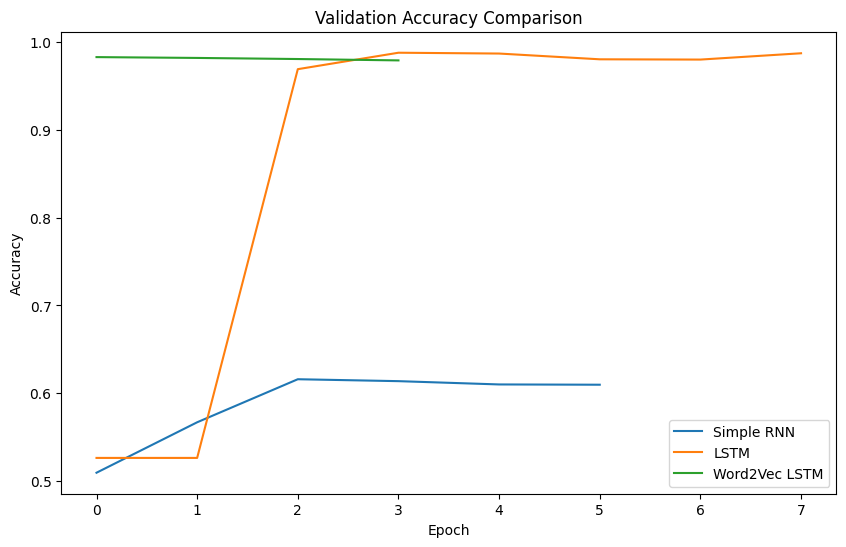

In [70]:
plt.figure(figsize=(10, 6))

# Simple RNN
plt.plot(
    history_rnn.history['val_accuracy'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

# Word2Vec LSTM
plt.plot(
    history_lstm_pre.history['val_accuracy'],
    label='Word2Vec LSTM'
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Training and Validation Loss Comparison

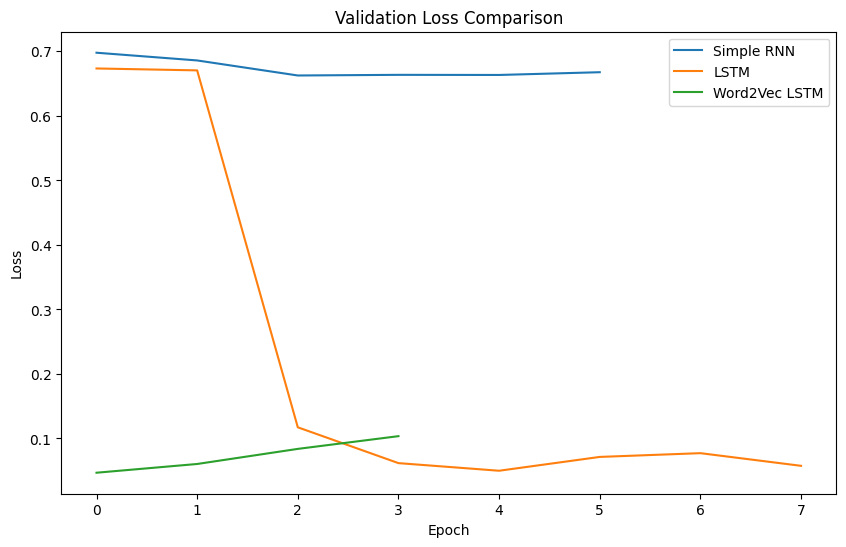

In [71]:
plt.figure(figsize=(10, 6))

# Simple RNN
plt.plot(
    history_rnn.history['val_loss'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM'
)

# Word2Vec LSTM
plt.plot(
    history_lstm_pre.history['val_loss'],
    label='Word2Vec LSTM'
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [72]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        lstm_pre_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Simple RNN,0.60900
1,LSTM,0.98600
2,Word2Vec LSTM,0.98575


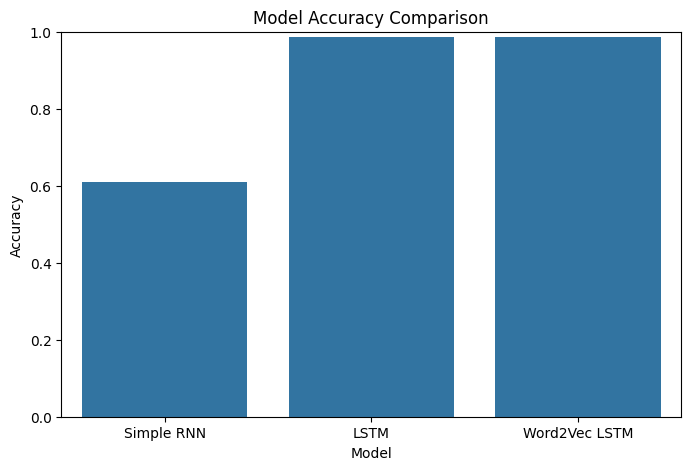

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [74]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.0 MB/s eta 0:00:00


In [75]:
import gensim.downloader as api

In [76]:
word2vec_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [77]:
print(word2vec_model['news'])

[-0.20825   0.47786   0.52196   1.0587   -0.10045  -1.1269   -1.2581
 -0.11041  -0.074125 -0.77976  -0.37942  -0.2486   -0.39224   0.42972
  0.9806    0.12668  -1.3772   -0.22793  -0.18497   0.41014   0.96781
  0.8916    0.84685   0.57416   0.46455  -1.7287   -0.63918   0.56256
 -0.12651   0.49711   3.3326    0.034399  0.46149  -0.44826  -1.1945
 -0.47593  -0.31927  -0.6442    0.089735  0.073952  0.70755   0.52948
 -0.12034  -0.46779   0.24722   0.28045  -0.62632   1.4458    0.51045
  0.74156 ]


In [78]:
word_index = tokenizer.word_index

embedding_dim = 50

## Create Embedding Matrix

In [79]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i < vocab_size:

        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 50)


## Build Word2Vec LSTM Model

In [80]:
model_w2v_lstm = Sequential()

model_w2v_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

model_w2v_lstm.add(LSTM(64))

model_w2v_lstm.add(Dropout(0.5))

model_w2v_lstm.add(Dense(1, activation='sigmoid'))

In [81]:
model_w2v_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [82]:
history_w2v_lstm = model_w2v_lstm.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.9367 - loss: 0.1742 - val_accuracy: 0.9591 - val_loss: 0.1141
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9639 - loss: 0.1064 - val_accuracy: 0.9619 - val_loss: 0.1161
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9677 - loss: 0.0925 - val_accuracy: 0.9731 - val_loss: 0.0691


In [83]:
w2v_lstm_loss, w2v_lstm_accuracy = model_w2v_lstm.evaluate(
    X_test_pad_pre,
    y_test
)

print("Word2Vec + LSTM Test Accuracy:", w2v_lstm_accuracy)
print("Word2Vec + LSTM Test Loss:", w2v_lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9625 - loss: 0.1067
Word2Vec + LSTM Test Accuracy: 0.9624999761581421
Word2Vec + LSTM Test Loss: 0.10673978179693222


In [84]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        w2v_lstm_accuracy
    ],
    'Loss': [
        rnn_loss,
        lstm_loss,
        w2v_lstm_loss
    ]
})

comparison_df

,Model,Accuracy,Loss
0,Simple RNN,0.6090,0.662179
1,LSTM,0.9860,0.053362
2,Word2Vec LSTM,0.9625,0.106740


# Real-Time News Prediction Function

In [85]:
def predict_news(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='pre',
        truncating='pre'
    )

    probability = model_w2v_lstm.predict(padded)[0][0]

    if probability >= 0.5:
        prediction = "True News"
    else:
        prediction = "Fake News"

    print("Original Text:", text)
    print("Cleaned Text :", cleaned)
    print("Prediction   :", prediction)
    print("Confidence   :", round(float(probability), 4))

In [86]:
predict_news(
    "NASA confirms new discovery about water on Mars after successful space mission."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Original Text: NASA confirms new discovery about water on Mars after successful space mission.
Cleaned Text : nasa confirms new discovery water mar successful space mission
Prediction   : True News
Confidence   : 0.6665


In [87]:
predict_news(
    "Reuters reports that the government approved a new international climate agreement."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Original Text: Reuters reports that the government approved a new international climate agreement.
Cleaned Text : reuters report government approved new international climate agreement
Prediction   : True News
Confidence   : 0.9909


# Error Analysis

In [88]:
w2v_pred_prob = model_w2v_lstm.predict(X_test_pad_pre)

w2v_pred_labels = (
    w2v_pred_prob > 0.5
).astype(int).flatten()

error_df = pd.DataFrame({
    'Text': X_test.values,
    'Actual': y_test.values,
    'Predicted': w2v_pred_labels
})

errors = error_df[
    error_df['Actual'] != error_df['Predicted']
]

print("Total Incorrect Predictions:", len(errors))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Total Incorrect Predictions: 150


In [89]:
errors.head(5)

,Text,Actual,Predicted
10,best yet message hollywood went viral cover th...,0,1
29,washington reuters yous senate ethic committee...,1,0
105,nancy pelosi obviously geographically challeng...,0,1
152,isle lewis scotland reuters donald trump playe...,1,0
173,another case love trump hate lol hate unhinged...,0,1


In [90]:
errors['Actual_Label'] = errors['Actual'].map({
    0: 'Fake',
    1: 'True'
})

errors['Predicted_Label'] = errors['Predicted'].map({
    0: 'Fake',
    1: 'True'
})

errors[
    ['Text', 'Actual_Label', 'Predicted_Label']
].head(5)

/tmp/ipykernel_1451/2301676934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual_Label'] = errors['Actual'].map({
/tmp/ipykernel_1451/2301676934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted_Label'] = errors['Predicted'].map({


,Text,Actual_Label,Predicted_Label
10,best yet message hollywood went viral cover th...,Fake,True
29,washington reuters yous senate ethic committee...,True,Fake
105,nancy pelosi obviously geographically challeng...,Fake,True
152,isle lewis scotland reuters donald trump playe...,True,Fake
173,another case love trump hate lol hate unhinged...,Fake,True


In [91]:
!pip install gradio

In [92]:
import gradio as gr

# Prediction Function
def detect_fake_news(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='pre',
        truncating='pre'
    )

    probability = model_lstm_pre.predict(padded)[0][0]

    if probability >= 0.5:
        prediction = "TRUE NEWS"
        confidence = f"{probability * 100:.2f}%"
    else:
        prediction = "FAKE NEWS"
        confidence = f"{(1 - probability) * 100:.2f}%"

    return f"""
Prediction: {prediction}

Confidence Score: {confidence}
"""


# Gradio Interface
interface = gr.Interface(
    fn=detect_fake_news,

    inputs=gr.Textbox(
        lines=8,
        placeholder="Enter news article or headline here...",
        label="News Text"
    ),

    outputs=gr.Textbox(
        label="Detection Result"
    ),

    title="📰 Fake News Detection System",

    description="""
This AI system detects whether a news article is REAL or FAKE using
Deep Learning (LSTM) and Natural Language Processing (NLP).
""",

    theme="soft"
)

# Launch App
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eaba0e484fa6c90644.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
